EDA Assignment

In [401]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import regex as re


In [402]:
match_details=pd.read_csv(r"E:\IOT ACademy\Submissions\EDA\IPL_dataset.csv")

In [403]:
match_details.head()


,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s
0,1,KL Rahul,14,14,2,670,132*,55.83,518,129.34,1,5,58,23
1,2,Shikhar Dhawan,17,17,3,618,106*,44.14,427,144.73,2,4,67,12
2,3,David Warner,16,16,2,548,85*,39.14,407,134.64,0,4,52,14
3,4,Shreyas Iyer,17,17,2,519,88*,34.60,421,123.27,0,3,40,16
4,5,Ishan Kishan,14,13,4,516,99,57.33,354,145.76,0,4,36,30


In [404]:
match_details.tail()

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s
128,129,Khaleel Ahmed,7,1,0,0,0*,0.0,2,0.0,0,0,0,0
129,130,Arshdeep Singh,8,1,0,0,0*,0.0,3,0.0,0,0,0,0
130,131,Daniel Sams,3,1,0,0,0*,0.0,2,0.0,0,0,0,0
131,132,Shreevats Goswami,2,2,0,0,0*,0.0,4,0.0,0,0,0,0
132,133,Trent Boult,15,1,0,0,0*,0.0,1,0.0,0,0,0,0


In [405]:
match_details.shape



(133, 14)

In [406]:
match_details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Jersey No      133 non-null    int64  
 1   Player         133 non-null    object 
 2   Matches        133 non-null    int64  
 3   Inns           133 non-null    int64  
 4   Not Out        133 non-null    int64  
 5   Runs           133 non-null    int64  
 6   Highest Score  133 non-null    object 
 7   Avg            133 non-null    float64
 8   Balls faced    133 non-null    int64  
 9   Strike rate    133 non-null    float64
 10  100            133 non-null    int64  
 11  50             133 non-null    int64  
 12  4s             133 non-null    int64  
 13  6s             133 non-null    int64  
dtypes: float64(2), int64(10), object(2)
memory usage: 14.7+ KB


no null value present in the data

Q1. What is the maximum number of matches played by an individual player in a season? Print the player name along with the number of matched played.

In [409]:
max_match_played= match_details.Matches.max()
player_list=match_details[match_details["Matches"]==max_match_played][["Player","Matches"]].set_index("Player")
player_list

,Matches
Player,
Shikhar Dhawan,17
Shreyas Iyer,17
Marcus Stoinis,17
Kagiso Rabada,17


Q2. Top 2 players with maximum Average who have scored atleast 2 half centuries ?

In [494]:
Top2=match_details[match_details["50"]>=2].sort_values(by="Avg",ascending=False).head(2)
Top2

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s,first_name,last_name,Cleaned_Highest_score,Boundary %,Notout %
36,37,Wriddhiman Saha,4,4,1,214,87,71.33,153,139.86,0,2,24,5,Wriddhiman,Saha,87,58.88,25.00
4,5,Ishan Kishan,14,13,4,516,99,57.33,354,145.76,0,4,36,30,Ishan,Kishan,99,62.79,30.77


Q3. Create 2 new columns based on Player name. First column will have first name and second column will have last name. Eg: for the player Shikhar Dhawan, Shikhar will be the first name and Dhawan will be the last name.

In [413]:
match_details[["first_name","last_name"]]=match_details["Player"].str.strip().str.split(" ",n=1,expand=True).fillna("")
match_details.head()

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s,first_name,last_name
0,1,KL Rahul,14,14,2,670,132*,55.83,518,129.34,1,5,58,23,KL,Rahul
1,2,Shikhar Dhawan,17,17,3,618,106*,44.14,427,144.73,2,4,67,12,Shikhar,Dhawan
2,3,David Warner,16,16,2,548,85*,39.14,407,134.64,0,4,52,14,David,Warner
3,4,Shreyas Iyer,17,17,2,519,88*,34.60,421,123.27,0,3,40,16,Shreyas,Iyer
4,5,Ishan Kishan,14,13,4,516,99,57.33,354,145.76,0,4,36,30,Ishan,Kishan


Q4. Create a new column (Cleaned_Highest_score) based on Highest score variable. Remove the Asterik(*) mark and convert the data type into INT.

In [415]:
match_details["Cleaned_Highest_score"]=match_details["Highest Score"].str.replace("*","")
match_details["Cleaned_Highest_score"]=match_details["Cleaned_Highest_score"].astype(int)
match_details.head()

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s,first_name,last_name,Cleaned_Highest_score
0,1,KL Rahul,14,14,2,670,132*,55.83,518,129.34,1,5,58,23,KL,Rahul,132
1,2,Shikhar Dhawan,17,17,3,618,106*,44.14,427,144.73,2,4,67,12,Shikhar,Dhawan,106
2,3,David Warner,16,16,2,548,85*,39.14,407,134.64,0,4,52,14,David,Warner,85
3,4,Shreyas Iyer,17,17,2,519,88*,34.60,421,123.27,0,3,40,16,Shreyas,Iyer,88
4,5,Ishan Kishan,14,13,4,516,99,57.33,354,145.76,0,4,36,30,Ishan,Kishan,99


Q5. Print the total number of centuries scored in the entire season.

In [417]:
Total_centuries=match_details["100"].sum()
Total_centuries

5

Q6. Print all the player names whose strike rate is less than the average strike rate of all players in entire season. Print the player name, his strike rate and average strike rate

In [488]:
below_SR_player=match_details[match_details["Strike rate"]<=match_details["Strike rate"].mean()]
below_SR_player

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s,first_name,last_name,Cleaned_Highest_score,Boundary %,Notout %
51,52,Ajinkya Rahane,9,8,0,113,60,14.12,107,105.60,0,1,12,2,Ajinkya,Rahane,60,53.10,0.00
55,56,Glenn Maxwell,13,11,4,108,32,15.42,106,101.88,0,0,9,0,Glenn,Maxwell,32,33.33,36.36
58,59,Vijay Shankar,7,5,1,97,52*,24.25,96,101.04,0,1,10,1,Vijay,Shankar,52,47.42,20.00
61,62,Josh Philippe,5,5,1,78,33,19.50,77,101.29,0,0,9,1,Josh,Philippe,33,53.85,20.00
62,63,Gurkeerat Singh,8,5,5,71,21*,0.00,80,88.75,0,0,8,0,Gurkeerat,Singh,21,45.07,100.00
65,66,Kedar Jadhav,8,5,2,62,26,20.66,66,93.93,0,0,7,0,Kedar,Jadhav,26,45.16,40.00
70,71,Yashasvi Jaiswal,3,3,0,40,34,13.33,44,90.90,0,0,2,2,Yashasvi,Jaiswal,34,50.00,0.00
71,72,Shreyas Gopal,14,5,1,37,23*,9.25,39,94.87,0,0,3,0,Shreyas,Gopal,23,32.43,20.00
77,78,Murali Vijay,3,3,0,32,21,10.66,43,74.41,0,0,4,0,Murali,Vijay,21,50.00,0.00
79,80,Chris Jordan,9,5,2,29,13,9.66,31,93.54,0,0,2,0,Chris,Jordan,13,27.59,40.00


Q7. Please check the correlation between the features and create a heat map.

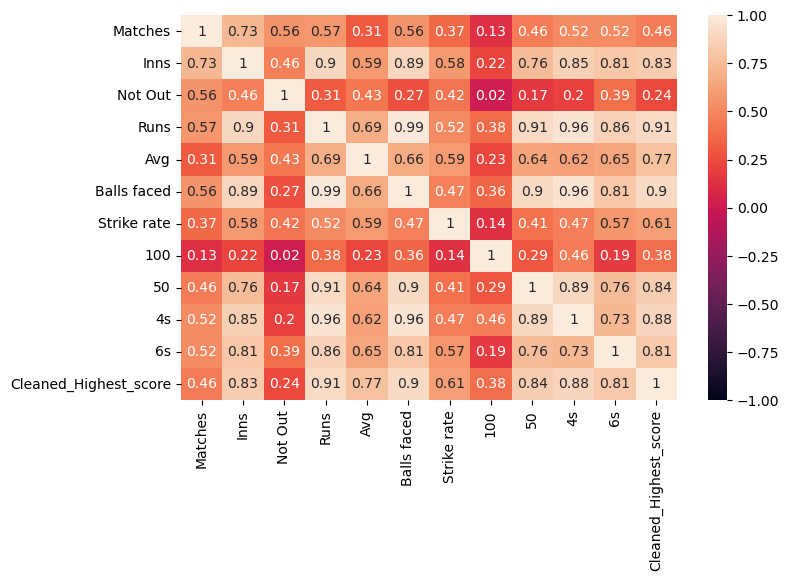

In [421]:
corr_matrix=match_details.drop(columns=["Jersey No"]).select_dtypes(include="number").corr()
plt.figure(figsize=(8,5))
sns.heatmap(corr_matrix,annot=True,vmin=-1,vmax=1)
plt.show()

Observations:
1. Runs have highly positive corr with Avg,ballfaced,50,4,6
2. Higher innings menas higher 50,4s,6s,Ballfaced,Runs,matches
3. Strikrate have positive corr with Avg,ballfaced

Q8. Check the list of players who has an average greater than 50 as well strike rate above 120. Print player name, average and strike rate.

In [424]:
player_list=match_details[(match_details["Avg"]>50) & (match_details["Strike rate"]>120)][["Player","Avg","Strike rate"]].set_index("Player")
player_list

,Avg,Strike rate
Player,,
KL Rahul,55.83,129.34
Ishan Kishan,57.33,145.76
Kieron Pollard,53.60,191.42
Wriddhiman Saha,71.33,139.86
Ruturaj Gaikwad,51.00,120.71
Deepak Hooda,101.00,142.25
Tom Curran,83.00,133.87


Q9. Please check the list of players who has an average greater than 40 and balls faced above 100. Print player name, average and balls faced.

In [496]:
player_list2=match_details[(match_details["Avg"]>40) & (match_details["Balls faced"]>100)][["Player","Avg","Balls faced"]].set_index("Player")
player_list2

,Avg,Balls faced
Player,,
KL Rahul,55.83,518
Shikhar Dhawan,44.14,427
Ishan Kishan,57.33,354
Virat Kohli,42.36,384
ABD Villiers,45.40,286
Faf Duplessis,40.81,319
Eoin Morgan,41.80,302
Kane Williamson,45.28,237
Chris Gayle,41.14,210


Q10. Players who scored atleast one century in this season. Create visualization.

In [428]:
centurians=match_details[match_details["100"]>0]
centurians

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s,first_name,last_name,Cleaned_Highest_score
0,1,KL Rahul,14,14,2,670,132*,55.83,518,129.34,1,5,58,23,KL,Rahul,132
1,2,Shikhar Dhawan,17,17,3,618,106*,44.14,427,144.73,2,4,67,12,Shikhar,Dhawan,106
13,14,Mayank Agarwal,11,11,0,424,106,38.54,271,156.45,1,2,44,15,Mayank,Agarwal,106
28,29,Ben Stokes,8,8,1,285,107*,40.71,200,142.50,1,1,36,7,Ben,Stokes,107


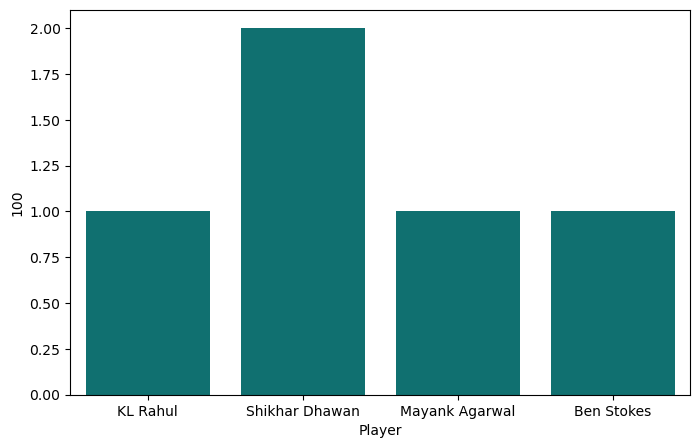

In [429]:
plt.figure(figsize=(8,5))
sns.barplot(x=centurians['Player'],y=centurians['100'],color="Teal")
plt.show()

Q11.Players who scored atleast 4 half centuries in this season.

In [490]:
fiftys=match_details[match_details["50"]>=4]
fiftys

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s,first_name,last_name,Cleaned_Highest_score,Boundary %,Notout %
0,1,KL Rahul,14,14,2,670,132*,55.83,518,129.34,1,5,58,23,KL,Rahul,132,55.22,14.29
1,2,Shikhar Dhawan,17,17,3,618,106*,44.14,427,144.73,2,4,67,12,Shikhar,Dhawan,106,55.02,17.65
2,3,David Warner,16,16,2,548,85*,39.14,407,134.64,0,4,52,14,David,Warner,85,53.28,12.50
4,5,Ishan Kishan,14,13,4,516,99,57.33,354,145.76,0,4,36,30,Ishan,Kishan,99,62.79,30.77
5,6,Quinton Kock,16,16,2,503,78*,35.92,358,140.50,0,4,46,22,Quinton,Kock,78,62.82,12.50
6,7,Suryakumar Yadav,16,15,3,480,79*,40.00,331,145.01,0,4,61,11,Suryakumar,Yadav,79,64.58,20.00
7,8,Devdutt Padikkal,15,15,0,473,74,31.53,379,124.80,0,5,51,8,Devdutt,Padikkal,74,53.28,0.00
9,10,ABD Villiers,15,14,4,454,73*,45.40,286,158.74,0,5,33,23,ABD,Villiers,73,59.47,28.57
10,11,Faf Duplessis,13,13,2,449,87*,40.81,319,140.75,0,4,42,14,Faf,Duplessis,87,56.12,15.38


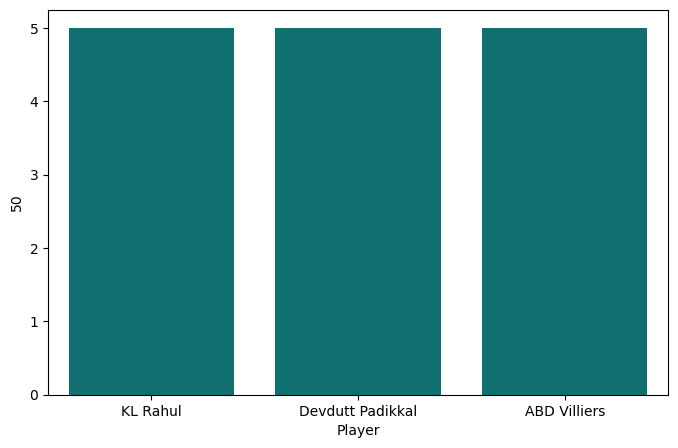

In [432]:
plt.figure(figsize=(8,5))
sns.barplot(x=fiftys['Player'],y=fiftys['50'],color="Teal")
plt.show()

Q12. Check the list of players who hit more than 45 boundaries and more than 10 sixes in this season.

In [492]:
player_list3=match_details[(match_details["4s"]>45) & (match_details["6s"]>10)][["Player","4s","6s"]].set_index("Player")
player_list3

,4s,6s
Player,,
KL Rahul,58,23
Shikhar Dhawan,67,12
David Warner,52,14
Quinton Kock,46,22
Suryakumar Yadav,61,11


Q13. Plot a histogram of number of matches played in a season by players.

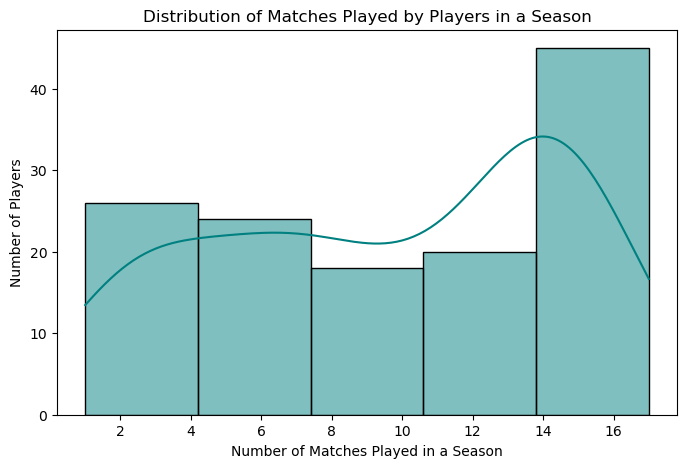

In [436]:
plt.figure(figsize=(8,5))
plt.xlabel("Number of Matches Played in a Season")
plt.ylabel("Number of Players")
plt.title("Distribution of Matches Played by Players in a Season")
sns.histplot(match_details['Matches'],binwidth=3,kde=True,color="Teal")
plt.show()

Q14. Plot the histogram of balls faced by players.

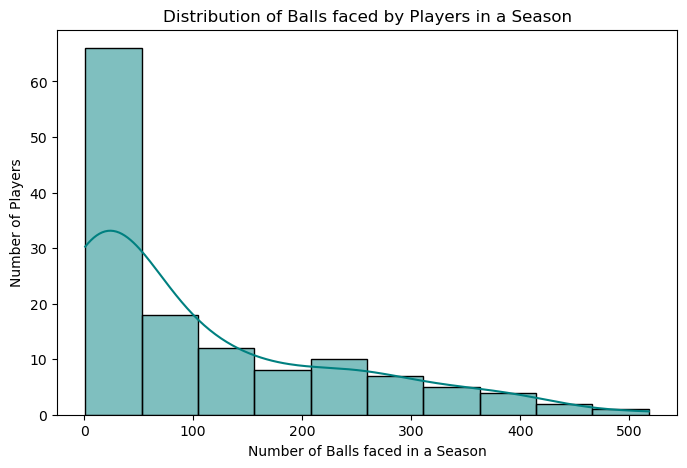

In [438]:
plt.figure(figsize=(8,5))
plt.xlabel("Number of Balls faced in a Season")
plt.ylabel("Number of Players")
plt.title("Distribution of Balls faced by Players in a Season")
sns.histplot(match_details['Balls faced'],kde=True,color="Teal",binwidth=50)
plt.show()

Q15. Top 10 players with most runs in a season.

In [440]:
Top10=match_details.sort_values(by="Runs",ascending=False).head(10)
Top10

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s,first_name,last_name,Cleaned_Highest_score
0,1,KL Rahul,14,14,2,670,132*,55.83,518,129.34,1,5,58,23,KL,Rahul,132
1,2,Shikhar Dhawan,17,17,3,618,106*,44.14,427,144.73,2,4,67,12,Shikhar,Dhawan,106
2,3,David Warner,16,16,2,548,85*,39.14,407,134.64,0,4,52,14,David,Warner,85
3,4,Shreyas Iyer,17,17,2,519,88*,34.60,421,123.27,0,3,40,16,Shreyas,Iyer,88
4,5,Ishan Kishan,14,13,4,516,99,57.33,354,145.76,0,4,36,30,Ishan,Kishan,99
5,6,Quinton Kock,16,16,2,503,78*,35.92,358,140.50,0,4,46,22,Quinton,Kock,78
6,7,Suryakumar Yadav,16,15,3,480,79*,40.00,331,145.01,0,4,61,11,Suryakumar,Yadav,79
7,8,Devdutt Padikkal,15,15,0,473,74,31.53,379,124.80,0,5,51,8,Devdutt,Padikkal,74
8,9,Virat Kohli,15,15,4,466,90*,42.36,384,121.35,0,3,23,11,Virat,Kohli,90
9,10,ABD Villiers,15,14,4,454,73*,45.40,286,158.74,0,5,33,23,ABD,Villiers,73


Q16. Print the players who played the match but didn't get the batting.

In [442]:
Not_batted=match_details[(match_details["Matches"]>0) & (match_details["Balls faced"]==0)]
Not_batted

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s,first_name,last_name,Cleaned_Highest_score


Every player got the batting

Q17. Create a new column to show the percentage of total runs scored in 4s and 6s. Then print the top 5 players with maximum percentage.

In [445]:
match_details["Boundary %"]=round(((match_details["4s"]*4+match_details["6s"]*6)/match_details["Runs"])*100,2)
match_details.sort_values(by="Boundary %",ascending=False).head()

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s,first_name,last_name,Cleaned_Highest_score,Boundary %
109,110,Andrew Tye,1,1,0,6,6,6.00,6,100.00,0,0,0,1,Andrew,Tye,6,100.00
48,49,Andre Russell,10,9,0,117,25,13.00,81,144.44,0,0,9,9,Andre,Russell,25,76.92
74,75,Chris Morris,9,5,1,34,25*,8.50,21,161.90,0,0,2,3,Chris,Morris,25,76.47
29,30,Hardik Pandya,14,13,5,281,60*,35.12,157,178.98,0,1,14,25,Hardik,Pandya,60,73.31
47,48,Sunil Narine,10,9,0,121,64,13.44,85,142.35,0,1,10,8,Sunil,Narine,64,72.73


Q18. Print the players with top 5 Not out percentages (Not Out percentage can be calculated as number of Not outs divided by Innings).

In [447]:
match_details["Notout %"]=round(((match_details["Not Out"])/match_details["Inns"])*100,2)
match_details.sort_values(by="Notout %",ascending=False).head()

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s,first_name,last_name,Cleaned_Highest_score,Boundary %,Notout %
122,123,Shahbaz Ahmed,2,1,1,1,1*,0.0,1,100.0,0,0,0,0,Shahbaz,Ahmed,1,0.00,100.0
97,98,Mohammad Nabi,1,1,1,11,11*,0.0,8,137.5,0,0,2,0,Mohammad,Nabi,11,72.73,100.0
114,115,T Natarajan,16,3,3,3,3*,0.0,5,60.0,0,0,0,0,T,Natarajan,3,0.00,100.0
116,117,Rahul Chahar,15,1,1,2,2*,0.0,4,50.0,0,0,0,0,Rahul,Chahar,2,0.00,100.0
113,114,Dhawal Kulkarni,1,1,1,3,3*,0.0,2,150.0,0,0,0,0,Dhawal,Kulkarni,3,0.00,100.0


Q19. Create visualization of top 10 players with highest number of sixes.

In [449]:
Top10_six_hitters=match_details.sort_values(by="6s",ascending=False).head(10)
Top10_six_hitters


,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s,first_name,last_name,Cleaned_Highest_score,Boundary %,Notout %
4,5,Ishan Kishan,14,13,4,516,99,57.33,354,145.76,0,4,36,30,Ishan,Kishan,99,62.79,30.77
15,16,Sanju Samson,14,14,1,375,85,28.84,236,158.89,0,3,21,26,Sanju,Samson,85,64.00,7.14
29,30,Hardik Pandya,14,13,5,281,60*,35.12,157,178.98,0,1,14,25,Hardik,Pandya,60,73.31,38.46
17,18,Nicholas Pooran,14,14,4,353,77,35.30,208,169.71,0,2,23,25,Nicholas,Pooran,77,68.56,28.57
14,15,Eoin Morgan,14,14,4,418,68*,41.80,302,138.41,0,1,32,24,Eoin,Morgan,68,65.07,28.57
9,10,ABD Villiers,15,14,4,454,73*,45.40,286,158.74,0,5,33,23,ABD,Villiers,73,59.47,28.57
27,28,Chris Gayle,7,7,0,288,99,41.14,210,137.14,0,3,15,23,Chris,Gayle,99,68.75,0.00
0,1,KL Rahul,14,14,2,670,132*,55.83,518,129.34,1,5,58,23,KL,Rahul,132,55.22,14.29
31,32,Kieron Pollard,16,12,7,268,60*,53.60,140,191.42,0,1,15,22,Kieron,Pollard,60,71.64,58.33
5,6,Quinton Kock,16,16,2,503,78*,35.92,358,140.50,0,4,46,22,Quinton,Kock,78,62.82,12.50


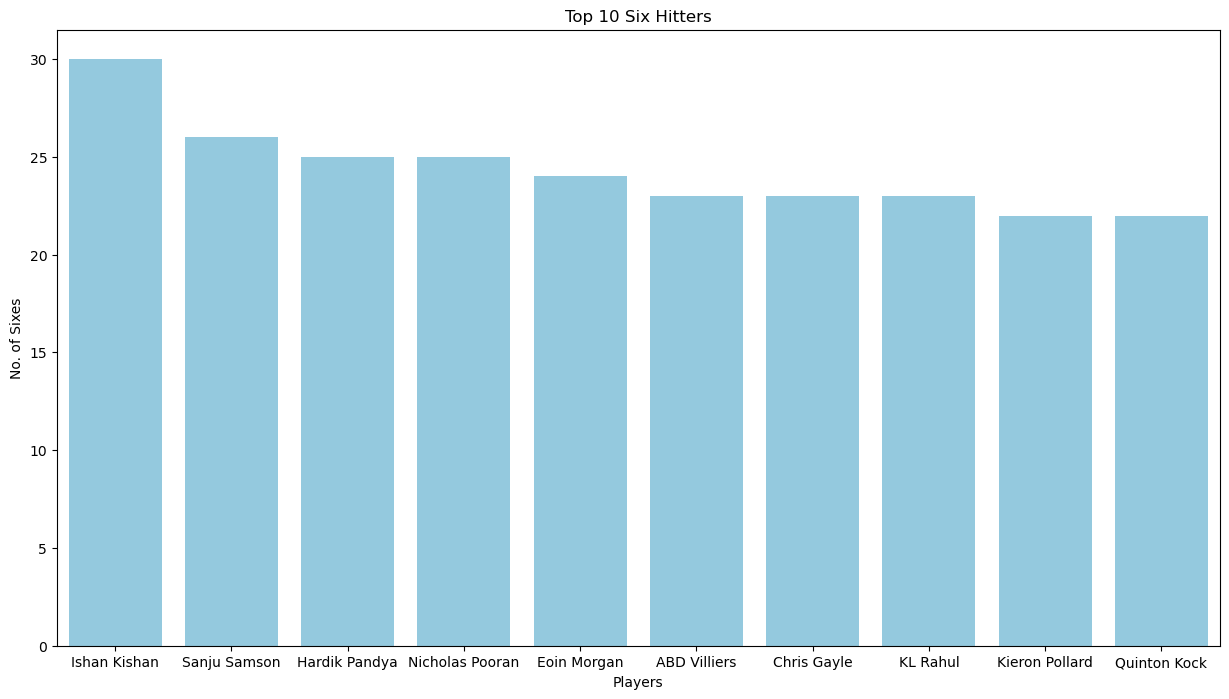

In [450]:
plt.figure(figsize=(15,8))
plt.title("Top 10 Six Hitters")
plt.xlabel("Players")
plt.ylabel("No. of Sixes")
sns.barplot(x=Top10_six_hitters['Player'],y=Top10_six_hitters['6s'],color="Skyblue")
plt.show()


Q20. Scatter plot of runs scored by a player v/s balls faced in a season. Then find the relationship between these 2 variables.


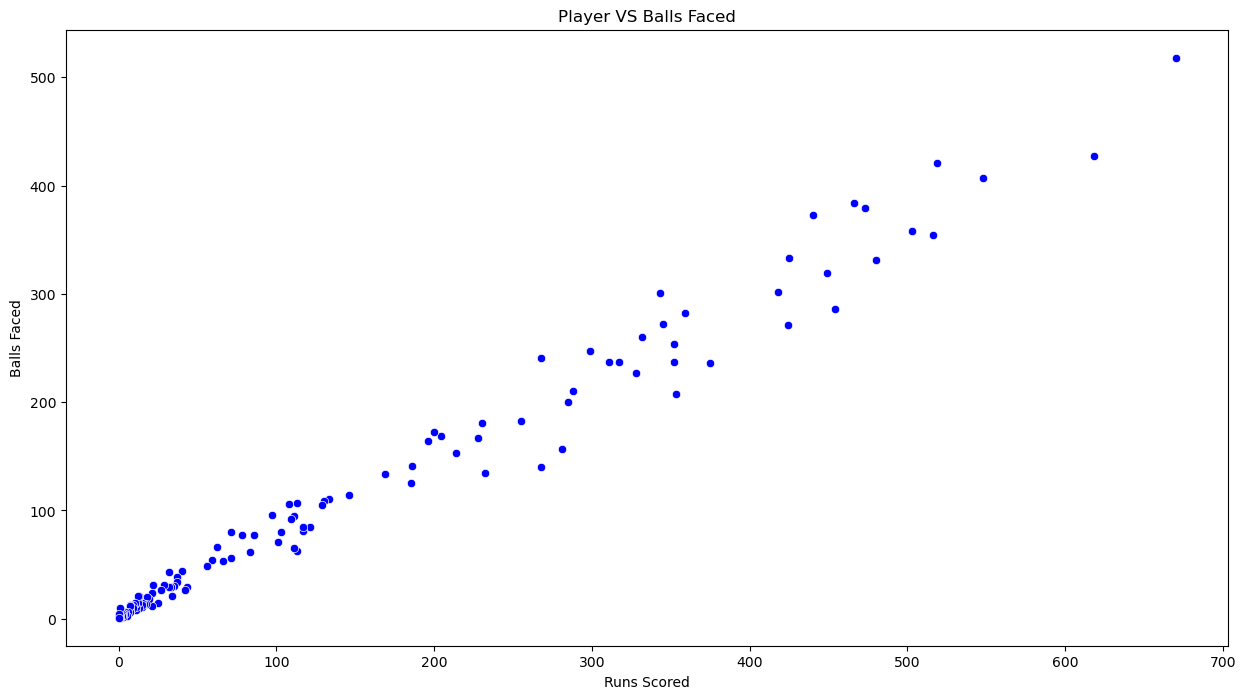

In [504]:
plt.figure(figsize=(15,8))
plt.title("Player VS Balls Faced")
plt.xlabel("Runs Scored")
plt.ylabel("Balls Faced")
sns.scatterplot(x=match_details['Runs'],y=match_details['Balls faced'],color="blue")
plt.show()

In [453]:
corr_Player_Ball=match_details[["Runs","Balls faced"]].corr()
corr_Player_Ball

,Runs,Balls faced
Runs,1.000000,0.989948
Balls faced,0.989948,1.000000
